In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# fetch dataset
forest_fires = fetch_ucirepo(id=162)

# data (as pandas dataframes)
X = forest_fires.data.features
y = forest_fires.data.targets

# metadata
print(forest_fires.metadata)

# variable information
print(forest_fires.variables)


{'uci_id': 162, 'name': 'Forest Fires', 'repository_url': 'https://archive.ics.uci.edu/dataset/162/forest+fires', 'data_url': 'https://archive.ics.uci.edu/static/public/162/data.csv', 'abstract': 'This is a difficult regression task, where the aim is to predict the burned area of forest fires, in the northeast region of Portugal, by using meteorological and other data (see details at: http://www.dsi.uminho.pt/~pcortez/forestfires).', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 517, 'num_features': 12, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['area'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2007, 'last_updated': 'Thu Jan 11 2024', 'dataset_doi': '10.24432/C5D88D', 'creators': ['Paulo Cortez', 'Anbal Morais'], 'intro_paper': {'ID': 368, 'type': 'NATIVE', 'title': 'A data mining approach to predict forest fires using meteorological da

In [ ]:
df=pd.DataFrame(X)
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


In [ ]:
df.columns

Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain'],
      dtype='object')

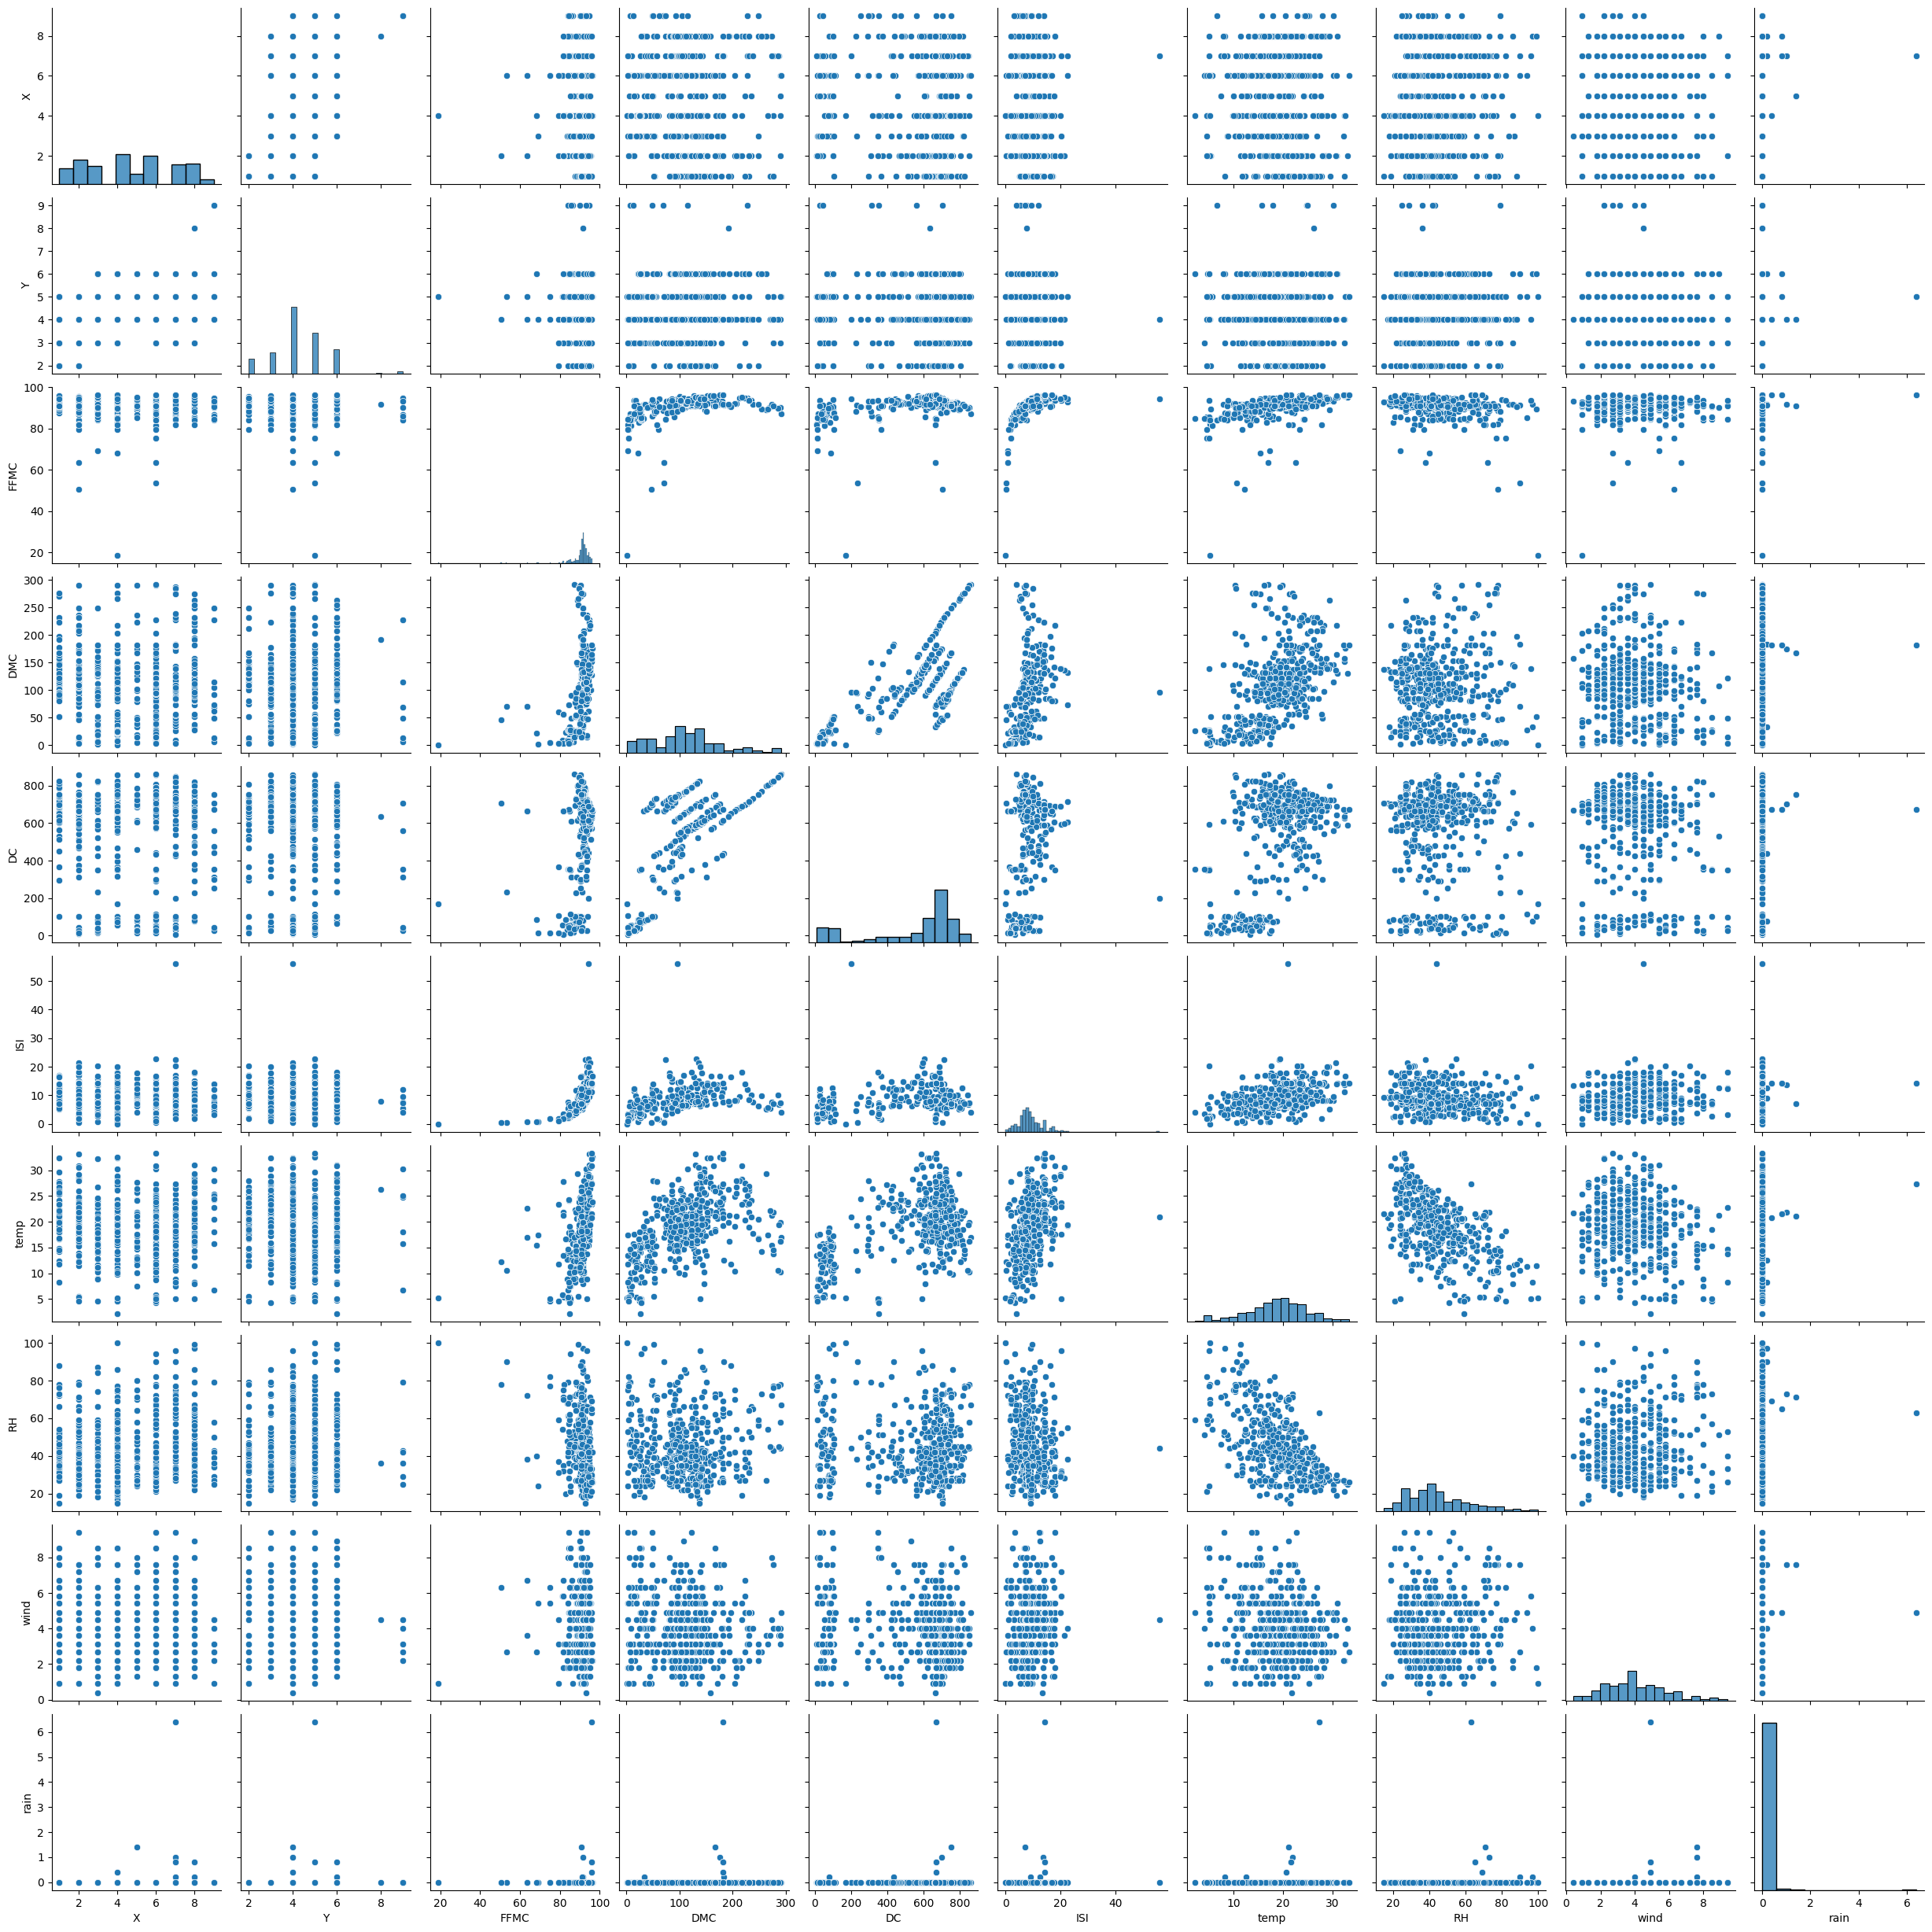

In [ ]:
df1=df.copy()
df1.drop(columns=['day','month'],inplace=True)
df1.head()
sns.pairplot(df1)

<Axes: >

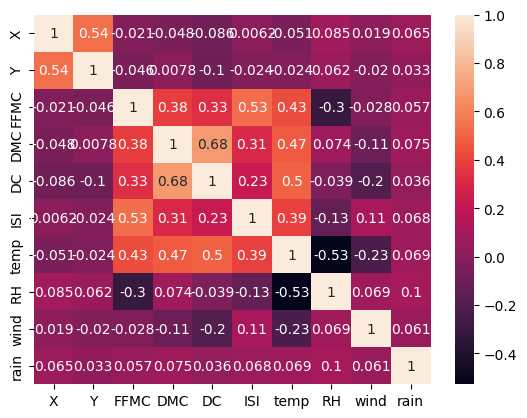

In [ ]:
sns.heatmap(df1.corr(),annot=True)

<Axes: ylabel='Count'>

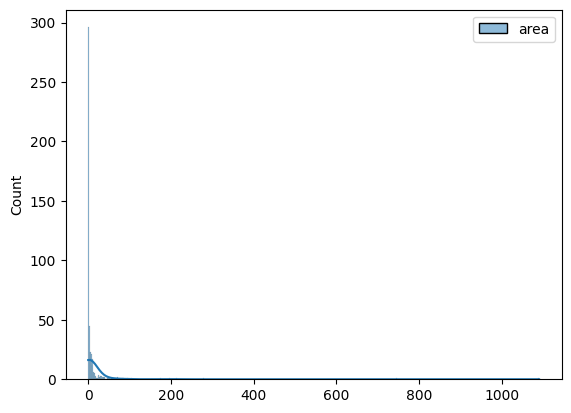

In [ ]:
sns.histplot(y,kde=True)

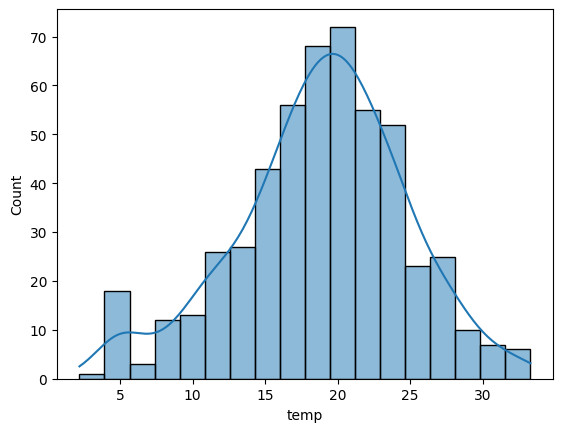

In [ ]:
sns.histplot(df1['temp'],kde=True)
df2=df1.copy()
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
new_temp=scaler.fit_transform(df2[["temp"]])



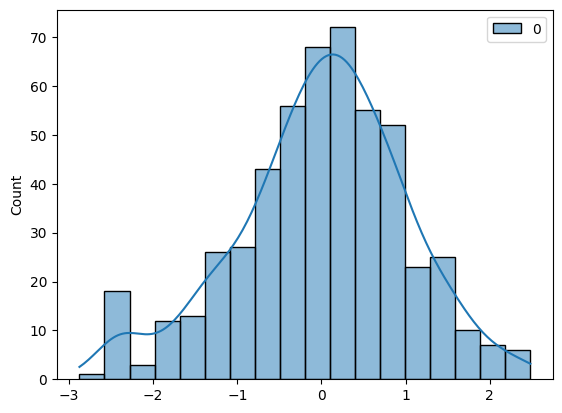

In [ ]:
sns.histplot(new_temp,kde=True)
df2["temp"]=new_temp


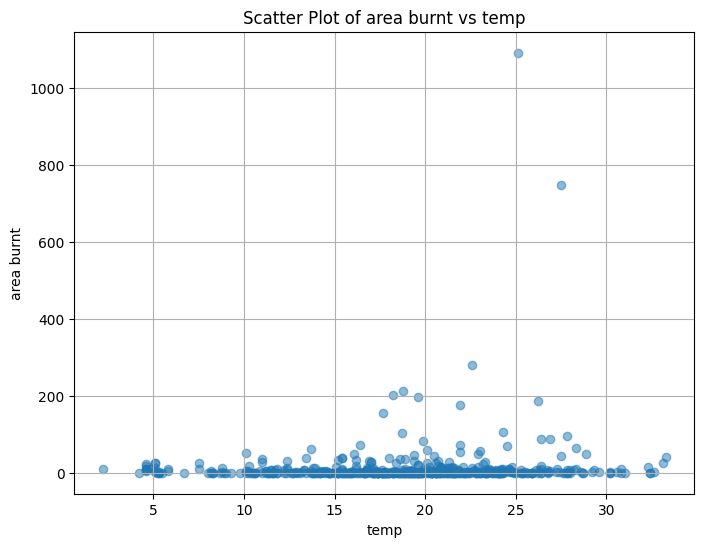

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X["temp"], y, alpha=0.5)
plt.xlabel("temp")
plt.ylabel("area burnt")
plt.title("Scatter Plot of area burnt vs temp")
plt.grid(True)
plt.show()

In [ ]:
model=LinearRegression()
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df2[['temp']],y,test_size=0.2,random_state=42)
reg=model.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

[[4.59840962]]
[11.13371709]


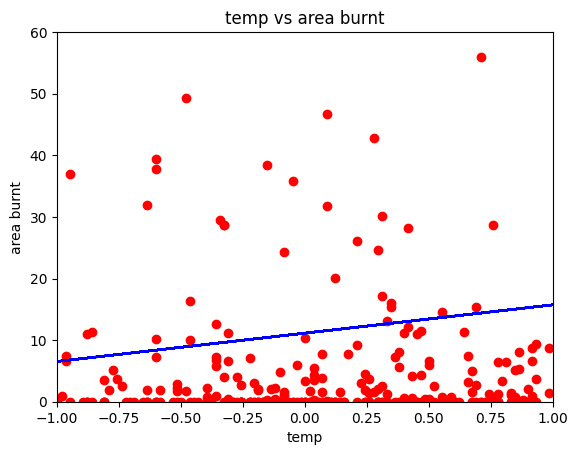

In [ ]:
y_pred=reg.predict(X_test)
plt.scatter(X_train,y_train,color='red')
plt.plot(X_test,y_pred,color='blue')
plt.xlim(-1,1)
plt.ylim(0,60)

plt.title('temp vs area burnt')
plt.xlabel('temp')
plt.ylabel('area burnt')
plt.show()

In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

R-squared: 0.0020
Mean squared error: 11764.5351
Root mean squared error: 108.4644
